In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
df=pd.read_csv('Salary Data.csv')

In [9]:
df.head()
df.tail()
df.describe()
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [15]:
df.isnull().sum()
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

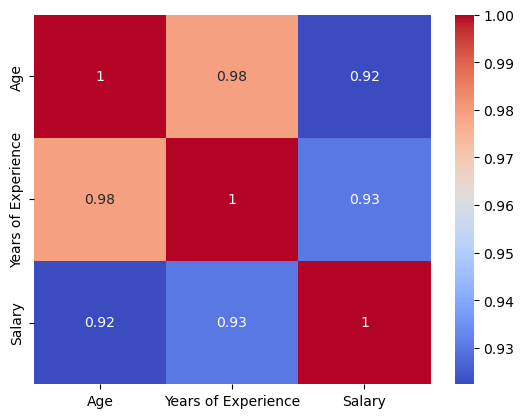

In [19]:
num_col=['Age','Years of Experience','Salary']
corr = df[num_col].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

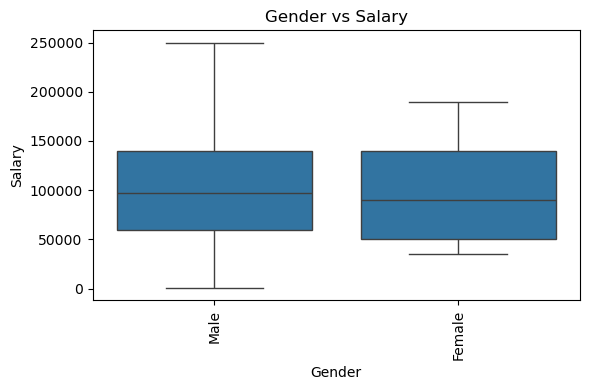

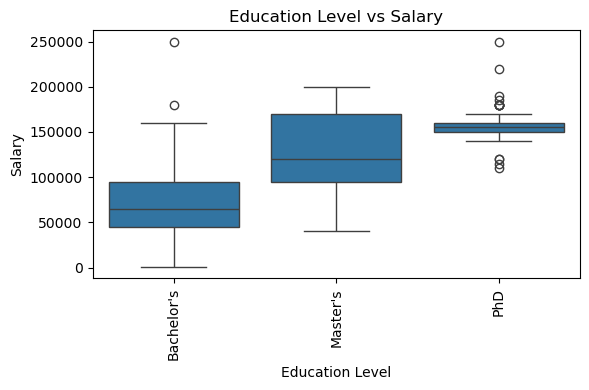

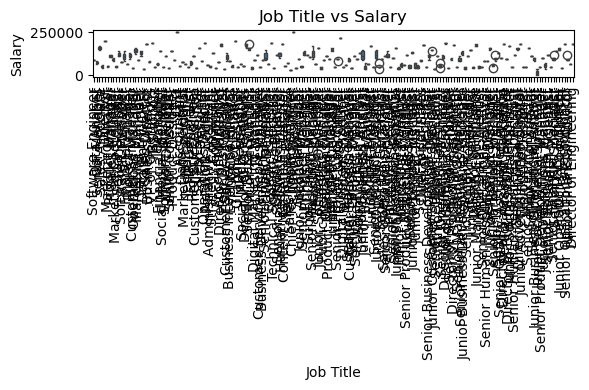

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_col = ['Gender','Education Level','Job Title']

for col in cat_col:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(data=df, x=col, y="Salary")
    
    plt.xticks(rotation=90)
    plt.title(f"{col} vs Salary")
    plt.tight_layout()
    
    plt.show()

In [26]:
df.drop(columns=['Job Title'], inplace=True)

In [27]:
df

,Age,Gender,Education Level,Years of Experience,Salary
0,32.0,Male,Bachelor's,5.0,90000.0
1,28.0,Female,Master's,3.0,65000.0
2,45.0,Male,PhD,15.0,150000.0
3,36.0,Female,Bachelor's,7.0,60000.0
4,52.0,Male,Master's,20.0,200000.0
...,...,...,...,...,...
370,35.0,Female,Bachelor's,8.0,85000.0
371,43.0,Male,Master's,19.0,170000.0
372,29.0,Female,Bachelor's,2.0,40000.0
373,34.0,Male,Bachelor's,7.0,90000.0


In [28]:
df['Gender']=df['Gender'].replace({
    'Male':0,
    'Female':1
})

In [30]:
df.rename(columns={
    'Gender':'is_male'
},inplace=True)

In [32]:
df['Education Level'].value_counts()

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

In [40]:
df=pd.get_dummies(df,columns=['Education Level'],drop_first=True)
df

,Age,is_male,Years of Experience,Salary,Education Level_Master's,Education Level_PhD
0,32.0,0,5.0,90000.0,False,False
1,28.0,1,3.0,65000.0,True,False
2,45.0,0,15.0,150000.0,False,True
3,36.0,1,7.0,60000.0,False,False
4,52.0,0,20.0,200000.0,True,False
...,...,...,...,...,...,...
370,35.0,1,8.0,85000.0,False,False
371,43.0,0,19.0,170000.0,True,False
372,29.0,1,2.0,40000.0,False,False
373,34.0,0,7.0,90000.0,False,False


In [42]:
df.columns

Index(['Age', 'is_male', 'Years of Experience', 'Salary',
       'Education Level_Master's', 'Education Level_PhD'],
      dtype='object')

In [43]:
df[["Education Level_Master's","Education Level_PhD"]]=df[["Education Level_Master's","Education Level_PhD"]].astype(int)

In [44]:
df

,Age,is_male,Years of Experience,Salary,Education Level_Master's,Education Level_PhD
0,32.0,0,5.0,90000.0,0,0
1,28.0,1,3.0,65000.0,1,0
2,45.0,0,15.0,150000.0,0,1
3,36.0,1,7.0,60000.0,0,0
4,52.0,0,20.0,200000.0,1,0
...,...,...,...,...,...,...
370,35.0,1,8.0,85000.0,0,0
371,43.0,0,19.0,170000.0,1,0
372,29.0,1,2.0,40000.0,0,0
373,34.0,0,7.0,90000.0,0,0


In [49]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df['Age']=scaler.fit_transform(df[['Age']])
df
df['Years of Experience']=scaler.fit_transform(df[['Years of Experience']])
df

,Age,is_male,Years of Experience,Salary,Education Level_Master's,Education Level_PhD
0,-0.769398,0,-0.768276,90000.0,0,0
1,-1.336003,1,-1.073702,65000.0,1,0
2,1.072068,0,0.758859,150000.0,0,1
3,-0.202793,1,-0.462849,60000.0,0,0
4,2.063627,0,1.522426,200000.0,1,0
...,...,...,...,...,...,...
370,-0.344444,1,-0.310135,85000.0,0,0
371,0.788766,0,1.369713,170000.0,1,0
372,-1.194352,1,-1.226416,40000.0,0,0
373,-0.486096,0,-0.462849,90000.0,0,0


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [61]:
y=df['Salary']
X=df.drop(columns=['Salary'])

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [67]:
# mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
k = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(r2)
print(adj_r2)

0.903302221764233
0.8962951363848296


In [71]:
y_pred

array([174397.94485083,  92739.7304696 , 129954.3162758 ,  87434.0606635 ,
       155650.66506871, 153470.74460953, 155412.89491725, 106274.78004172,
        58094.21861415, 104017.16012387, 136809.94569049, 157592.81537643,
        37929.58521857,  87601.18414105, 126217.38342327,  58094.21861415,
        65490.38486054,  53411.32798827,  76545.7845008 , 102537.84718919,
       124275.23311555, 111724.78040318, 161100.66543017,  61441.9979751 ,
        87434.0606635 ,  48595.83136725, 168496.83167656,  45248.0520063 ,
       122468.72601052, 152364.84502899,  39408.89815326, 127996.42583064,
        54434.98522029, 147865.34533074,  89080.49707573,  16441.56511829,
       177761.46434921,  52566.51879403, 149811.51121567,  59962.68504042,
        44858.89851472,  91260.41753491, 168725.91447534, 170661.0119983 ,
        45248.0520063 , 149733.811757  , 118825.23275409,  54345.5612014 ,
        48907.28540016,  37540.431727  , 159683.31181671,  78414.25092706,
       124348.91699701, 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


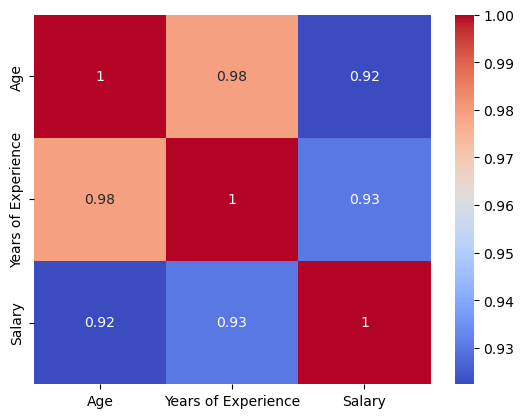

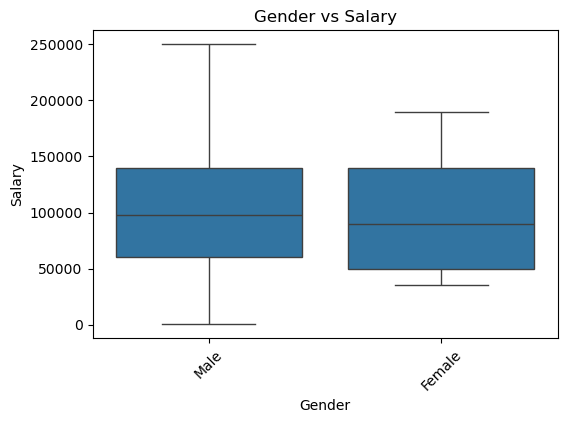

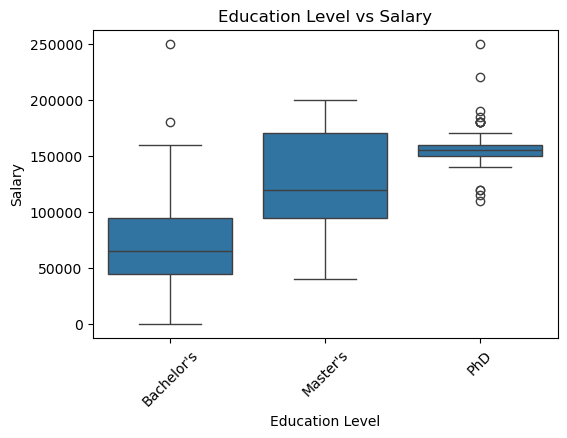

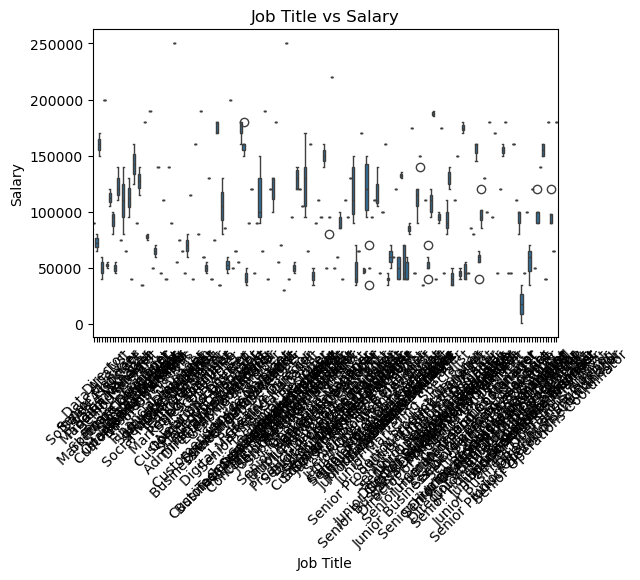

R2: 0.903302221764233
Adjusted R2: 0.8962951363848296


In [72]:
# More Refined Version : 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Salary Data.csv')

# Basic checks
df.head()
df.info()
df.describe()

# Missing values
df.isnull().sum()
df.dropna(inplace=True)

# ---------------- EDA ----------------
num_col = ['Age','Years of Experience','Salary']
corr = df[num_col].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Categorical analysis
cat_col = ['Gender','Education Level','Job Title']

for col in cat_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col, y="Salary")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Salary")
    plt.show()

# ---------------- Feature Engineering ----------------

# Drop high-cardinality column
df.drop(columns=['Job Title'], inplace=True)

# Encode Gender (correct logic)
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# One-hot encoding
df = pd.get_dummies(df, columns=['Education Level'], drop_first=True, dtype=int)

# ---------------- Split ----------------
from sklearn.model_selection import train_test_split

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- Scaling (Correct 🔥) ----------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['Age','Years of Experience']
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

# ---------------- Model ----------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# ---------------- Prediction ----------------
y_pred = model.predict(X_test)

# ---------------- Evaluation ----------------
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

n = len(y_test)
k = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print("R2:", r2)
print("Adjusted R2:", adj_r2)